# Advanced Customer Journey Analysis

### Markov Chains · Cohort Analysis · Predictive Modeling · Engagement Scoring
### Statistical Testing · Temporal Patterns · RFM Segmentation · Deep-Dive Visuals

In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 28.8 MB/s  0:00:00 27.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn]━━━━━ 2/3 [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
from itertools import combinations

In [3]:
warnings.filterwarnings("ignore")
os.makedirs("outputs_advanced", exist_ok=True)
 
df = pd.read_csv("../data/customer_journey.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df.sort_values(["UserID", "Timestamp"], inplace=True)
df.reset_index(drop=True, inplace=True)

In [4]:
# Derived time columns
df["hour"] = df["Timestamp"].dt.hour
df["day_of_week"] = df["Timestamp"].dt.day_name()
df["month"] = df["Timestamp"].dt.to_period("M")
df["date"] = df["Timestamp"].dt.date
 
STAGE_ORDER = ["home", "product_page", "cart", "checkout", "confirmation"]
STAGE_LABELS = ["Home", "Product Page", "Cart", "Checkout", "Confirmation"]
 
print(f"Loaded {len(df):,} events | {df['UserID'].nunique():,} users | "
      f"{df['SessionID'].nunique():,} sessions")

Loaded 12,719 events | 1,872 users | 5,000 sessions


## 1️⃣  MARKOV CHAIN TRANSITION ANALYSIS

In [5]:
# Add a virtual "exit" state for sessions that end
transitions = []
for _, grp in df.groupby("SessionID"):
    pages = grp.sort_values("Timestamp")["PageType"].tolist()
    for i in range(len(pages) - 1):
        transitions.append((pages[i], pages[i + 1]))
    transitions.append((pages[-1], "exit"))  # session ends
 
trans_df = pd.DataFrame(transitions, columns=["from_state", "to_state"])
trans_matrix = pd.crosstab(trans_df["from_state"], trans_df["to_state"], normalize="index")
trans_matrix = trans_matrix.round(4)


Transition Probability Matrix:
to_state      home  product_page   cart  checkout  confirmation   exit
from_state                                                            
home           0.0         0.797  0.000     0.000         0.000  0.203
product_page   0.0         0.000  0.401     0.000         0.000  0.599
cart           0.0         0.000  0.000     0.702         0.000  0.298
checkout       0.0         0.000  0.000     0.000         0.899  0.101
confirmation   0.0         0.000  0.000     0.000         0.000  1.000


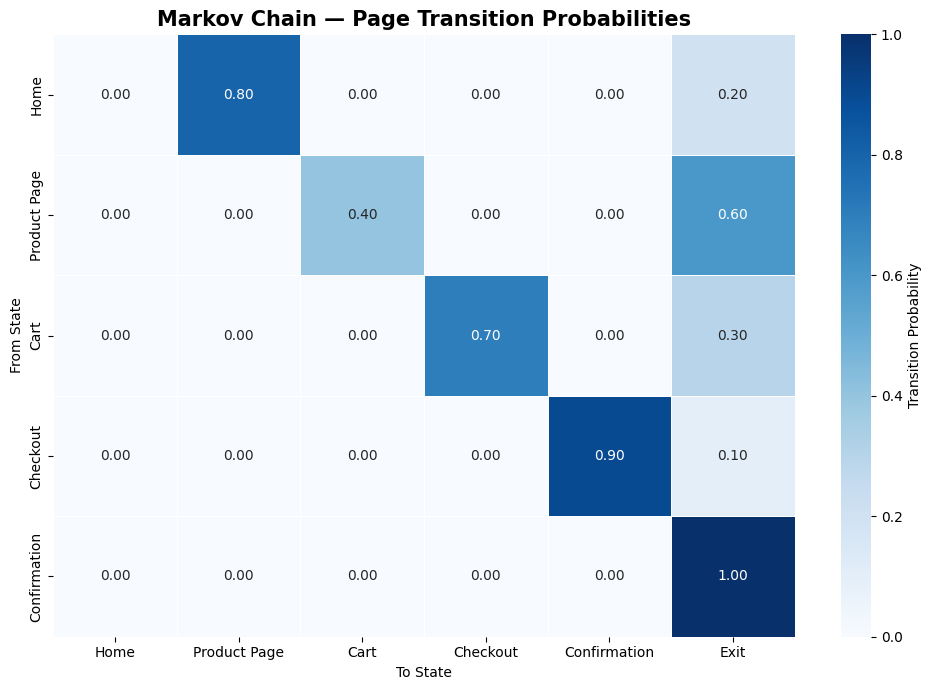

Saved 01_markov_transition_heatmap.png


In [14]:
# Reorder
all_states = STAGE_ORDER + ["exit"]
trans_matrix = trans_matrix.reindex(index=STAGE_ORDER, columns=all_states, fill_value=0)
 
print("\nTransition Probability Matrix:")
print(trans_matrix.round(3).to_string())
 
# Heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(trans_matrix, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5,
            xticklabels=STAGE_LABELS + ["Exit"], yticklabels=STAGE_LABELS, ax=ax,
            cbar_kws={"label": "Transition Probability"})
ax.set_title("Markov Chain — Page Transition Probabilities", fontsize=15, fontweight="bold")
ax.set_ylabel("From State")
ax.set_xlabel("To State")
plt.tight_layout()
plt.savefig("outputs_advanced/01_markov_transition_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 01_markov_transition_heatmap.png")

In [15]:
# Absorption probability: P(reaching purchase from each state)
# Using fundamental matrix approach
transient = STAGE_ORDER[:-1]  # all except confirmation
absorbing = ["confirmation", "exit"]
 
# Build Q matrix (transient-to-transient) and R matrix (transient-to-absorbing)
full = trans_matrix.reindex(index=STAGE_ORDER, columns=all_states, fill_value=0)
Q = full.loc[transient, transient].values
R = full.loc[transient, absorbing].values
I = np.eye(len(transient))
try:
    N = np.linalg.inv(I - Q)  # Fundamental matrix
    B = N @ R  # Absorption probabilities
    absorption_df = pd.DataFrame(B, index=transient, columns=absorbing)
    print("\nAbsorption Probabilities (reaching each end state):")
    print(absorption_df.round(4).to_string())
except np.linalg.LinAlgError:
    print("Singular matrix — skipping absorption calc")


Absorption Probabilities (reaching each end state):
              confirmation    exit
home                0.2020  0.7980
product_page        0.2534  0.7466
cart                0.6316  0.3684
checkout            0.8994  0.1006


## 2️⃣  TEMPORAL PATTERN ANALYSIS

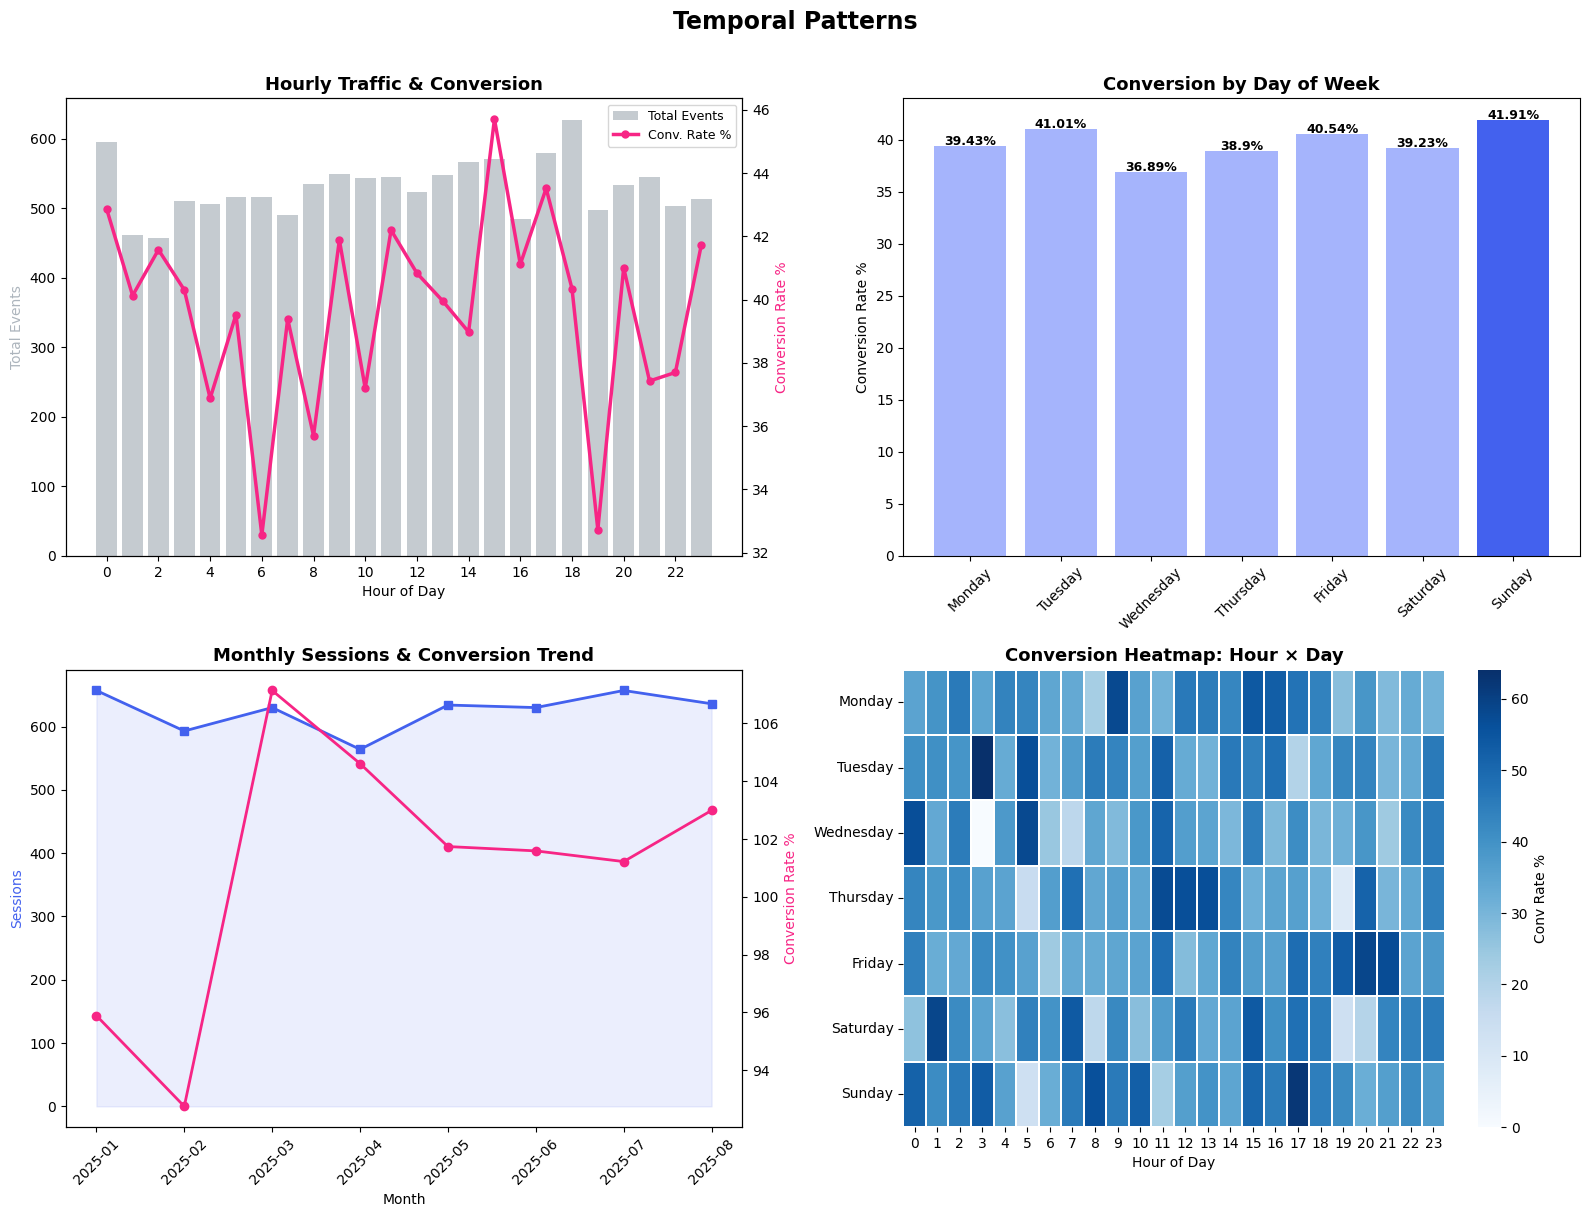

Saved 02_temporal_patterns.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
 
# 2a: Hourly conversion rate
hourly = df.groupby("hour").agg(
    events=("Purchased", "count"),
    purchases=("Purchased", "sum"),
).reset_index()
hourly["conv_rate"] = (hourly["purchases"] / hourly["events"] * 100).round(2)
 
axes[0, 0].bar(hourly["hour"], hourly["events"], color="#adb5bd", alpha=0.7, label="Total Events")
ax2 = axes[0, 0].twinx()
ax2.plot(hourly["hour"], hourly["conv_rate"], color="#f72585", linewidth=2.5,
         marker="o", markersize=5, label="Conv. Rate %")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_ylabel("Total Events", color="#adb5bd")
ax2.set_ylabel("Conversion Rate %", color="#f72585")
axes[0, 0].set_title("Hourly Traffic & Conversion", fontsize=13, fontweight="bold")
axes[0, 0].set_xticks(range(0, 24, 2))
lines1, labels1 = axes[0, 0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
 
# 2b: Day-of-week conversion
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = df.groupby("day_of_week").agg(
    events=("Purchased", "count"),
    purchases=("Purchased", "sum"),
).reindex(dow_order)
dow["conv_rate"] = (dow["purchases"] / dow["events"] * 100).round(2)
 
colors_dow = ["#4361ee" if v == dow["conv_rate"].max() else "#a5b4fc" for v in dow["conv_rate"]]
axes[0, 1].bar(dow.index, dow["conv_rate"], color=colors_dow)
axes[0, 1].set_ylabel("Conversion Rate %")
axes[0, 1].set_title("Conversion by Day of Week", fontsize=13, fontweight="bold")
axes[0, 1].tick_params(axis="x", rotation=45)
for i, (d, v) in enumerate(zip(dow.index, dow["conv_rate"])):
    axes[0, 1].text(i, v + 0.1, f"{v}%", ha="center", fontsize=9, fontweight="bold")
 
# 2c: Monthly trend
monthly = df.groupby("month").agg(
    users=("UserID", "nunique"),
    purchasers=("Purchased", "sum"),
    sessions=("SessionID", "nunique"),
).reset_index()
monthly["conv_rate"] = (monthly["purchasers"] / monthly["sessions"] * 100).round(2)
monthly["month_str"] = monthly["month"].astype(str)
 
axes[1, 0].plot(monthly["month_str"], monthly["sessions"], marker="s",
                color="#4361ee", linewidth=2, label="Sessions")
axes[1, 0].fill_between(monthly["month_str"], monthly["sessions"], alpha=0.1, color="#4361ee")
ax3 = axes[1, 0].twinx()
ax3.plot(monthly["month_str"], monthly["conv_rate"], marker="o",
         color="#f72585", linewidth=2, label="Conv. Rate %")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Sessions", color="#4361ee")
ax3.set_ylabel("Conversion Rate %", color="#f72585")
axes[1, 0].set_title("Monthly Sessions & Conversion Trend", fontsize=13, fontweight="bold")
axes[1, 0].tick_params(axis="x", rotation=45)
 
# 2d: Heatmap — hour vs day
pivot_conv = df.pivot_table(values="Purchased", index="day_of_week", columns="hour",
                            aggfunc="mean").reindex(dow_order) * 100
sns.heatmap(pivot_conv, cmap="Blues", ax=axes[1, 1], linewidths=0.3,
            cbar_kws={"label": "Conv Rate %"}, fmt=".1f")
axes[1, 1].set_title("Conversion Heatmap: Hour × Day", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("Hour of Day")
 
plt.suptitle("Temporal Patterns", fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outputs_advanced/02_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 02_temporal_patterns.png")

In [18]:
# Best/worst times
best_hour = hourly.loc[hourly["conv_rate"].idxmax()]
worst_hour = hourly.loc[hourly["conv_rate"].idxmin()]
best_day = dow["conv_rate"].idxmax()
print(f"\nBest hour: {int(best_hour['hour'])}:00 ({best_hour['conv_rate']}% conv)")
print(f"Worst hour: {int(worst_hour['hour'])}:00 ({worst_hour['conv_rate']}% conv)")
print(f"Best day: {best_day} ({dow.loc[best_day, 'conv_rate']}% conv)")


Best hour: 15:00 (45.71% conv)
Worst hour: 6:00 (32.56% conv)
Best day: Sunday (41.91% conv)


## 3️⃣  COHORT ANALYSIS — MONTHLY RETENTION

In [19]:
# Assign each user to a cohort = month of first visit
user_first = df.groupby("UserID")["Timestamp"].min().reset_index()
user_first["cohort"] = user_first["Timestamp"].dt.to_period("M")
user_first.rename(columns={"Timestamp": "first_visit"}, inplace=True)
 
df_cohort = df.merge(user_first[["UserID", "cohort"]], on="UserID")
df_cohort["activity_month"] = df_cohort["Timestamp"].dt.to_period("M")
df_cohort["month_offset"] = (
    (df_cohort["activity_month"] - df_cohort["cohort"]).apply(lambda x: x.n if pd.notna(x) else 0)
)
 
# Retention table
cohort_table = df_cohort.groupby(["cohort", "month_offset"])["UserID"].nunique().reset_index()
cohort_table = cohort_table.pivot(index="cohort", columns="month_offset", values="UserID")
cohort_sizes = cohort_table.iloc[:, 0]
retention = cohort_table.div(cohort_sizes, axis=0) * 100
 
print("Retention Table (%)")
print(retention.round(1).to_string())

Retention Table (%)
month_offset      0     1     2     3     4     5     6     7
cohort                                                       
2025-01       100.0  23.9  27.1  24.4  28.4  26.8  28.2  24.2
2025-02       100.0  25.6  26.2  25.6  25.4  25.9  30.1   NaN
2025-03       100.0  22.9  29.5  25.7  29.8  28.1   NaN   NaN
2025-04       100.0  26.2  28.7  22.1  30.3   NaN   NaN   NaN
2025-05       100.0  29.3  25.3  28.0   NaN   NaN   NaN   NaN
2025-06       100.0  27.1  28.0   NaN   NaN   NaN   NaN   NaN
2025-07       100.0  22.0   NaN   NaN   NaN   NaN   NaN   NaN
2025-08       100.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN


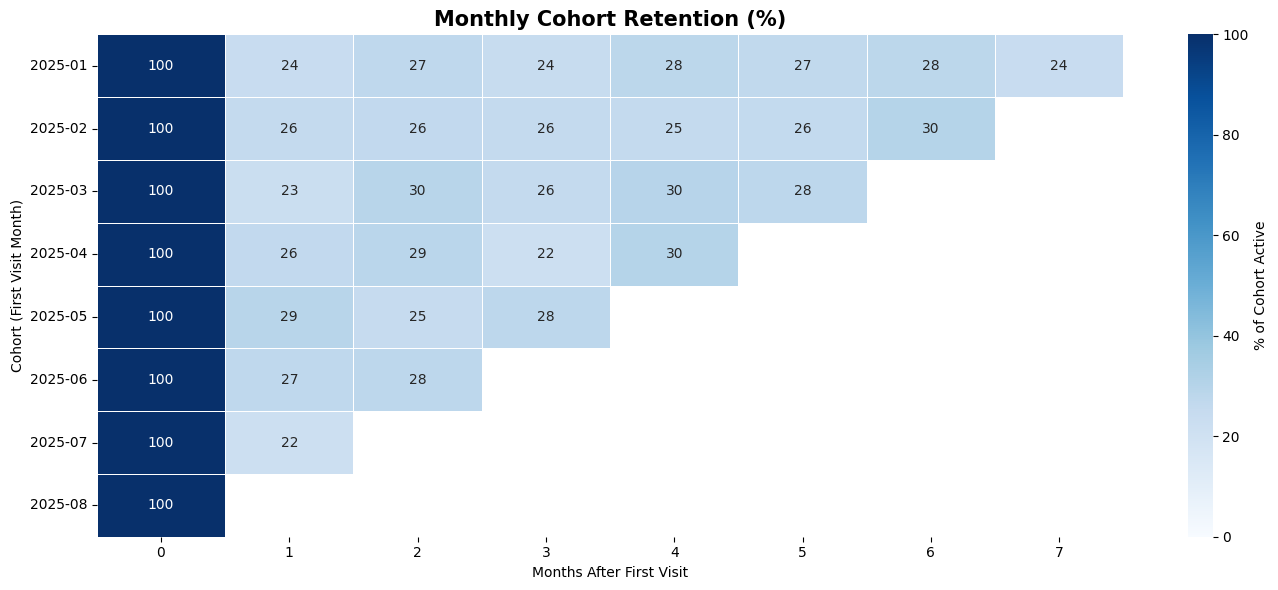

Saved 03_cohort_retention.png


In [20]:
# Retention heatmap
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(retention.round(1), annot=True, fmt=".0f", cmap="Blues", linewidths=0.5,
            ax=ax, cbar_kws={"label": "% of Cohort Active"}, vmin=0, vmax=100)
ax.set_title("Monthly Cohort Retention (%)", fontsize=15, fontweight="bold")
ax.set_xlabel("Months After First Visit")
ax.set_ylabel("Cohort (First Visit Month)")
yticklabels = [str(p) for p in retention.index]
ax.set_yticklabels(yticklabels, rotation=0)
plt.tight_layout()
plt.savefig("outputs_advanced/03_cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 03_cohort_retention.png")

In [21]:
# Cohort conversion rates
cohort_conv = df_cohort.groupby("cohort").agg(
    users=("UserID", "nunique"),
    purchasers=("Purchased", "max"),  # per-event, so sum
).reset_index()
# Recalculate: unique purchasers per cohort
cohort_purchasers = (
    df_cohort[df_cohort["Purchased"] == 1]
    .groupby("cohort")["UserID"].nunique().reset_index()
    .rename(columns={"UserID": "buyers"})
)
cohort_conv = cohort_conv.merge(cohort_purchasers, on="cohort", how="left").fillna(0)
cohort_conv["conv_rate"] = (cohort_conv["buyers"] / cohort_conv["users"] * 100).round(1)
print("\nCohort Conversion Rates")
print(cohort_conv[["cohort", "users", "buyers", "conv_rate"]].to_string(index=False))


Cohort Conversion Rates
 cohort  users  buyers  conv_rate
2025-01    557     271       48.7
2025-02    386     175       45.3
2025-03    292     124       42.5
2025-04    195      88       45.1
2025-05    150      57       38.0
2025-06    118      35       29.7
2025-07    100      25       25.0
2025-08     74      17       23.0


## 4️⃣  ENGAGEMENT SCORING MODEL

In [22]:
user_features = df.groupby("UserID").agg(
    total_sessions=("SessionID", "nunique"),
    total_events=("PageType", "count"),
    unique_pages=("PageType", "nunique"),
    total_time=("TimeOnPage_seconds", "sum"),
    avg_time_per_page=("TimeOnPage_seconds", "mean"),
    max_items_in_cart=("ItemsInCart", "max"),
    days_active=("date", "nunique"),
    purchased=("Purchased", "max"),
    deepest_stage=("PageType", lambda x: max(
        [STAGE_ORDER.index(p) for p in x if p in STAGE_ORDER]
    )),
).reset_index()
 
# Date span
user_dates = df.groupby("UserID")["Timestamp"].agg(["min", "max"]).reset_index()
user_dates["lifespan_days"] = (user_dates["max"] - user_dates["min"]).dt.days + 1
user_features = user_features.merge(user_dates[["UserID", "lifespan_days"]], on="UserID")
 
# Frequency = sessions per active-span day
user_features["frequency"] = (user_features["total_sessions"] / user_features["lifespan_days"]).clip(upper=1)
 
# Normalize components 0-100 for scoring
def norm_0_100(s):
    return ((s - s.min()) / (s.max() - s.min()) * 100).fillna(0)
 
user_features["score_depth"]     = norm_0_100(user_features["deepest_stage"])
user_features["score_frequency"] = norm_0_100(user_features["total_sessions"])
user_features["score_intensity"] = norm_0_100(user_features["total_time"])
user_features["score_breadth"]   = norm_0_100(user_features["unique_pages"])
user_features["score_cart"]      = norm_0_100(user_features["max_items_in_cart"])
 
# Weighted composite
user_features["engagement_score"] = (
    0.30 * user_features["score_depth"] +
    0.25 * user_features["score_frequency"] +
    0.20 * user_features["score_intensity"] +
    0.15 * user_features["score_breadth"] +
    0.10 * user_features["score_cart"]
).round(1)
 
# Tiers
user_features["engagement_tier"] = pd.cut(
    user_features["engagement_score"],
    bins=[0, 25, 50, 75, 100],
    labels=["Cold", "Warm", "Hot", "Power User"],
    include_lowest=True,
)
 
tier_summary = user_features.groupby("engagement_tier", observed=True).agg(
    users=("UserID", "count"),
    avg_score=("engagement_score", "mean"),
    conversion_rate=("purchased", "mean"),
).round(3)
tier_summary["conversion_rate"] = (tier_summary["conversion_rate"] * 100).round(1)
 
print("Engagement Tiers")
print(tier_summary.to_string())

Engagement Tiers
                 users  avg_score  conversion_rate
engagement_tier                                   
Cold               580     15.334              0.0
Warm               457     34.536              1.1
Hot                719     63.413             93.3
Power User         116     80.472            100.0


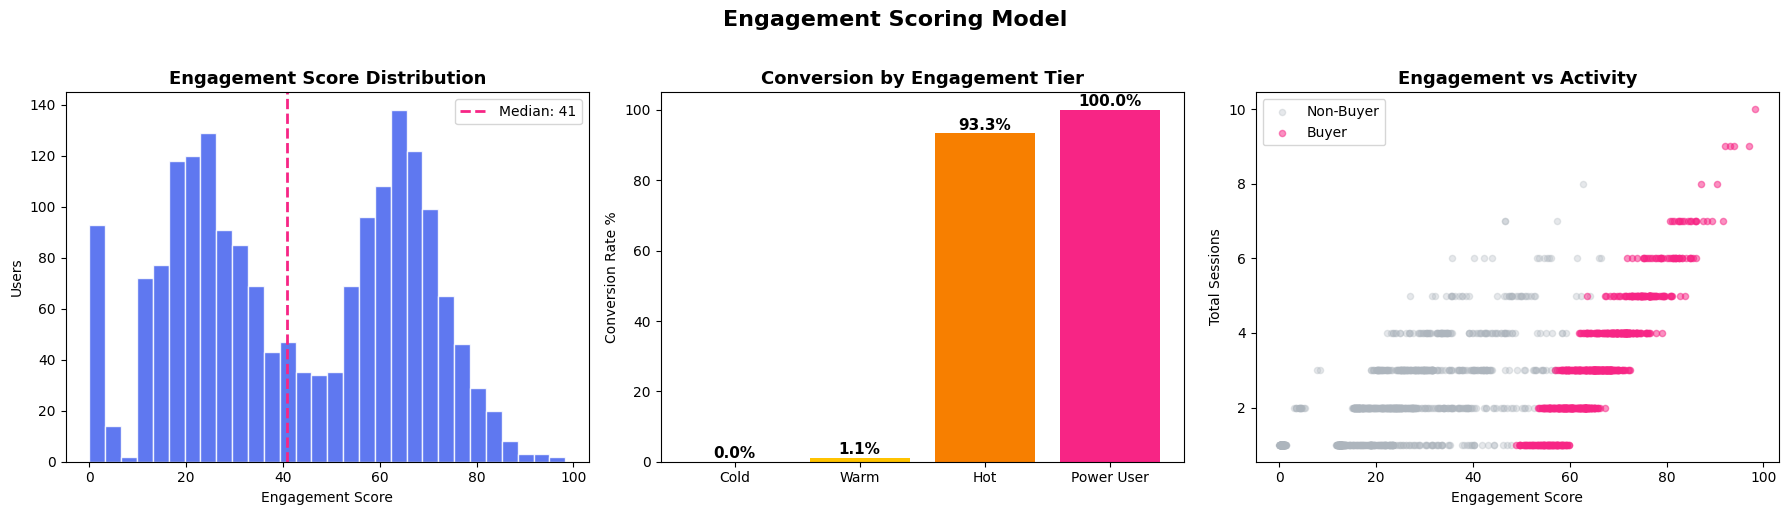

Saved 04_engagement_scoring.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# 4a: Score distribution
axes[0].hist(user_features["engagement_score"], bins=30, color="#4361ee", edgecolor="white", alpha=0.85)
axes[0].axvline(user_features["engagement_score"].median(), color="#f72585",
                linestyle="--", linewidth=2, label=f"Median: {user_features['engagement_score'].median():.0f}")
axes[0].set_xlabel("Engagement Score")
axes[0].set_ylabel("Users")
axes[0].set_title("Engagement Score Distribution", fontsize=13, fontweight="bold")
axes[0].legend()
 
# 4b: Tier conversion
tier_colors = {"Cold": "#adb5bd", "Warm": "#ffc300", "Hot": "#f77f00", "Power User": "#f72585"}
bar_colors = [tier_colors.get(t, "#4361ee") for t in tier_summary.index]
axes[1].bar(tier_summary.index, tier_summary["conversion_rate"], color=bar_colors)
for i, (tier, row) in enumerate(tier_summary.iterrows()):
    axes[1].text(i, row["conversion_rate"] + 1, f"{row['conversion_rate']}%",
                 ha="center", fontweight="bold", fontsize=11)
axes[1].set_ylabel("Conversion Rate %")
axes[1].set_title("Conversion by Engagement Tier", fontsize=13, fontweight="bold")
 
# 4c: Score vs conversion scatter
buyers = user_features[user_features["purchased"] == 1]
non_buyers = user_features[user_features["purchased"] == 0]
axes[2].scatter(non_buyers["engagement_score"], non_buyers["total_sessions"],
                alpha=0.3, s=20, color="#adb5bd", label="Non-Buyer")
axes[2].scatter(buyers["engagement_score"], buyers["total_sessions"],
                alpha=0.5, s=20, color="#f72585", label="Buyer")
axes[2].set_xlabel("Engagement Score")
axes[2].set_ylabel("Total Sessions")
axes[2].set_title("Engagement vs Activity", fontsize=13, fontweight="bold")
axes[2].legend()
 
plt.suptitle("Engagement Scoring Model", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs_advanced/04_engagement_scoring.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 04_engagement_scoring.png")

## 5️⃣  PREDICTIVE MODEL — PURCHASE PROBABILITY

In [24]:
# Prepare features
le_device = LabelEncoder()
le_ref = LabelEncoder()
le_country = LabelEncoder()
 
model_df = user_features.copy()
# Merge primary device/referral/country from mode
user_meta = df.groupby("UserID").agg(
    primary_device=("DeviceType", lambda x: x.mode().iloc[0]),
    primary_referral=("ReferralSource", lambda x: x.mode().iloc[0]),
    primary_country=("Country", lambda x: x.mode().iloc[0]),
).reset_index()
model_df = model_df.merge(user_meta, on="UserID")
 
model_df["device_enc"] = le_device.fit_transform(model_df["primary_device"])
model_df["referral_enc"] = le_ref.fit_transform(model_df["primary_referral"])
model_df["country_enc"] = le_country.fit_transform(model_df["primary_country"])
 
feature_cols = [
    "total_sessions", "total_events", "unique_pages", "total_time",
    "avg_time_per_page", "max_items_in_cart", "days_active",
    "deepest_stage", "lifespan_days", "frequency",
    "device_enc", "referral_enc", "country_enc",
]
 
X = model_df[feature_cols].values
y = model_df["purchased"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42,
                                                     stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


📈 Logistic Regression  — Test AUC: 1.0000 | 5-Fold CV AUC: 1.0000
📈 Random Forest        — Test AUC: 1.0000 | 5-Fold CV AUC: 1.0000

Classification Report (Random Forest)
              precision    recall  f1-score   support

   Non-Buyer       1.00      1.00      1.00       270
       Buyer       1.00      1.00      1.00       198

    accuracy                           1.00       468
   macro avg       1.00      1.00      1.00       468
weighted avg       1.00      1.00      1.00       468

Feature Importance (Top 10)
  avg_time_per_page         0.0024
  frequency                 0.0031
  lifespan_days             0.0051
  total_sessions            0.0080
  days_active               0.0133
  max_items_in_cart         0.0253
  total_time                0.0683
  total_events              0.1118
  unique_pages              0.3663
  deepest_stage             0.3955


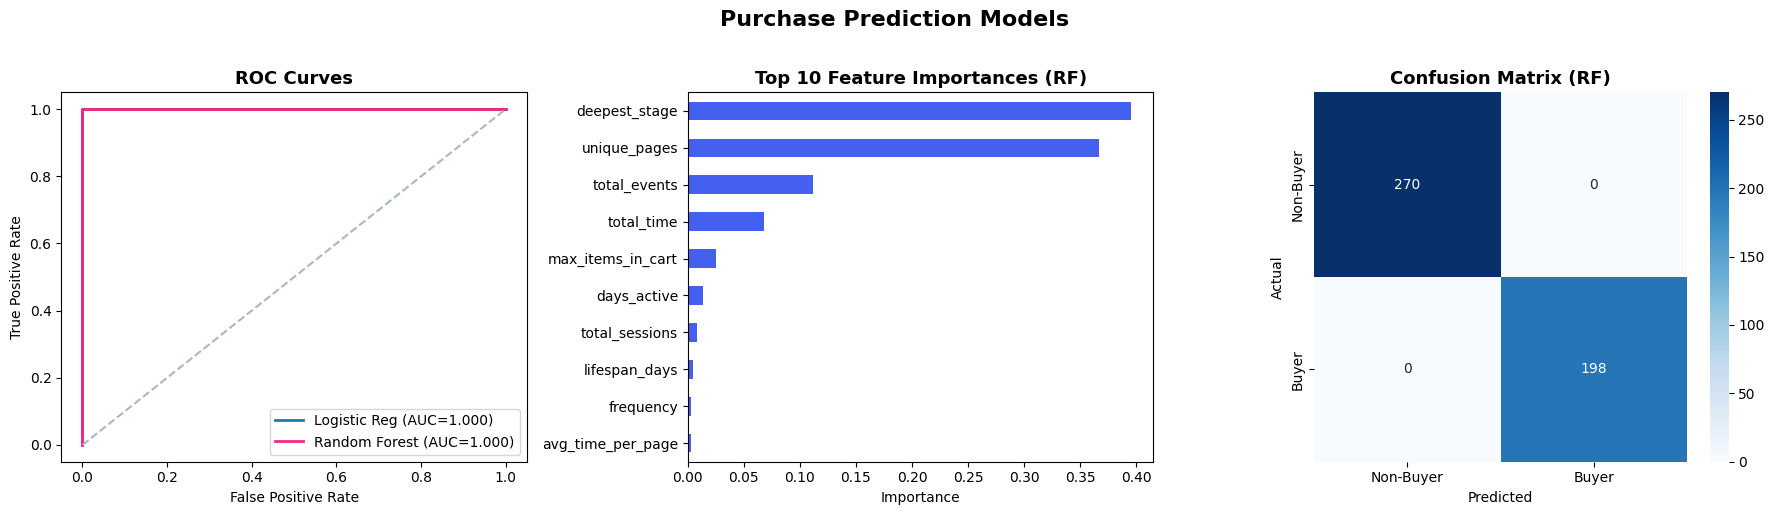

Saved 05_predictive_model.png


In [26]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)
lr_cv = cross_val_score(lr, X_train_sc, y_train, cv=5, scoring="roc_auc").mean()
 
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="roc_auc").mean()
 
print(f"\n📈 Logistic Regression  — Test AUC: {lr_auc:.4f} | 5-Fold CV AUC: {lr_cv:.4f}")
print(f"📈 Random Forest        — Test AUC: {rf_auc:.4f} | 5-Fold CV AUC: {rf_cv:.4f}")
 
print("\nClassification Report (Random Forest)")
print(classification_report(y_test, rf.predict(X_test), target_names=["Non-Buyer", "Buyer"]))
 
# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
print("Feature Importance (Top 10)")
for f, v in feat_imp.tail(10).items():
    print(f"  {f:25s} {v:.4f}")
 
# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# 5a: ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
axes[0].plot(fpr_lr, tpr_lr, label=f"Logistic Reg (AUC={lr_auc:.3f})", linewidth=2)
axes[0].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.3f})", linewidth=2, color="#f72585")
axes[0].plot([0, 1], [0, 1], "--", color="#adb5bd")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
 
# 5b: Feature importance
feat_imp.tail(10).plot.barh(ax=axes[1], color="#4361ee")
axes[1].set_xlabel("Importance")
axes[1].set_title("Top 10 Feature Importances (RF)", fontsize=13, fontweight="bold")
 
# 5c: Confusion matrix
cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Non-Buyer", "Buyer"], yticklabels=["Non-Buyer", "Buyer"])
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_title("Confusion Matrix (RF)", fontsize=13, fontweight="bold")
 
plt.suptitle("Purchase Prediction Models", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs_advanced/05_predictive_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 05_predictive_model.png")

## 6️⃣  STATISTICAL SIGNIFICANCE TESTS

In [27]:
# Chi-Square: Device × Conversion
device_ct = pd.crosstab(df["DeviceType"], df["Purchased"])
chi2_dev, p_dev, dof_dev, _ = stats.chi2_contingency(device_ct)
print(f"\n🔬 Chi-Square: Device vs Conversion")
print(f"   χ² = {chi2_dev:.4f}, p = {p_dev:.6f}, df = {dof_dev}")
print(f"   {'Significant' if p_dev < 0.05 else 'Not significant'} at α=0.05")
 
# Chi-Square: Referral × Conversion
ref_ct = pd.crosstab(df["ReferralSource"], df["Purchased"])
chi2_ref, p_ref, dof_ref, _ = stats.chi2_contingency(ref_ct)
print(f"\n🔬 Chi-Square: Referral Source vs Conversion")
print(f"   χ² = {chi2_ref:.4f}, p = {p_ref:.6f}, df = {dof_ref}")
print(f"   {'Significant' if p_ref < 0.05 else 'Not significant'} at α=0.05")
 
# Chi-Square: Country × Conversion
country_ct = pd.crosstab(df["Country"], df["Purchased"])
chi2_co, p_co, dof_co, _ = stats.chi2_contingency(country_ct)
print(f"\n🔬 Chi-Square: Country vs Conversion")
print(f"   χ² = {chi2_co:.4f}, p = {p_co:.6f}, df = {dof_co}")
print(f"   {'Significant' if p_co < 0.05 else 'Not significant'} at α=0.05")
 
# Mann-Whitney U: Session duration (converters vs non)
sessions = df.groupby("SessionID").agg(
    duration=("TimeOnPage_seconds", "sum"),
    purchased=("Purchased", "max"),
).reset_index()
conv_dur = sessions[sessions["purchased"] == 1]["duration"]
nonconv_dur = sessions[sessions["purchased"] == 0]["duration"]
u_stat, p_mw = stats.mannwhitneyu(conv_dur, nonconv_dur, alternative="two-sided")
print(f"\n🔬 Mann-Whitney U: Session Duration (Converter vs Non)")
print(f"   U = {u_stat:.0f}, p = {p_mw:.6f}")
print(f"   {'Significant' if p_mw < 0.05 else 'Not significant'} at α=0.05")
print(f"   Converter median: {conv_dur.median():.0f}s vs Non-converter: {nonconv_dur.median():.0f}s")
 
# Effect sizes: Cramér's V
def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0
 
print(f"\nEffect Sizes (Cramér's V):")
print(f"Device:   {cramers_v(device_ct):.4f}")
print(f"Referral: {cramers_v(ref_ct):.4f}")
print(f"Country:  {cramers_v(country_ct):.4f}")


🔬 Chi-Square: Device vs Conversion
   χ² = 0.1985, p = 0.905531, df = 2
   Not significant at α=0.05

🔬 Chi-Square: Referral Source vs Conversion
   χ² = 9.8121, p = 0.020232, df = 3
   Significant at α=0.05

🔬 Chi-Square: Country vs Conversion
   χ² = 15.3529, p = 0.017683, df = 6
   Significant at α=0.05

🔬 Mann-Whitney U: Session Duration (Converter vs Non)
   U = 3934658, p = 0.000000
   Significant at α=0.05
   Converter median: 484s vs Non-converter: 179s

Effect Sizes (Cramér's V):
Device:   0.0040
Referral: 0.0278
Country:  0.0347


## 7️⃣  RFM SEGMENTATION

In [29]:
ref_date = df["Timestamp"].max() + pd.Timedelta(days=1)
 
rfm = df.groupby("UserID").agg(
    recency=("Timestamp", lambda x: (ref_date - x.max()).days),
    frequency=("SessionID", "nunique"),
    monetary=("TimeOnPage_seconds", "sum"),  # proxy: total engagement time
).reset_index()
 
# Score each dimension 1-4 (rank-based to handle ties/low-cardinality)
for col in ["recency", "frequency", "monetary"]:
    ascending = (col == "recency")  # lower recency = better → ascending rank
    rfm[f"{col}_rank"] = rfm[col].rank(method="first", ascending=ascending)
    rfm[f"{col}_score"] = pd.qcut(rfm[f"{col}_rank"], q=4, labels=[1, 2, 3, 4]).astype(int)
    rfm.drop(columns=[f"{col}_rank"], inplace=True)
 
rfm["rfm_score"] = rfm["recency_score"] + rfm["frequency_score"] + rfm["monetary_score"]
 
# Label segments
def rfm_label(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal"
    elif score >= 6:
        return "Potential"
    elif score >= 4:
        return "At Risk"
    else:
        return "Hibernating"
 
rfm["rfm_segment"] = rfm["rfm_score"].apply(rfm_label)
 
# Merge purchase info
rfm = rfm.merge(user_features[["UserID", "purchased"]], on="UserID")
 
rfm_summary = rfm.groupby("rfm_segment").agg(
    users=("UserID", "count"),
    avg_rfm=("rfm_score", "mean"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    conv_rate=("purchased", "mean"),
).round(2)
rfm_summary["conv_rate"] = (rfm_summary["conv_rate"] * 100).round(1)
rfm_summary.sort_values("avg_rfm", ascending=False, inplace=True)
 
print("RFM Segment Summary")
print(rfm_summary.to_string())

RFM Segment Summary
             users  avg_rfm  avg_recency  avg_frequency  conv_rate
rfm_segment                                                       
Champions      500    10.98       136.09           1.27       14.0
Loyal          428     8.51        77.45           2.05       30.0
Potential      434     6.50        60.86           2.92       51.0
At Risk        377     4.47        34.97           4.12       69.0
Hibernating    133     3.00        13.11           5.05       86.0


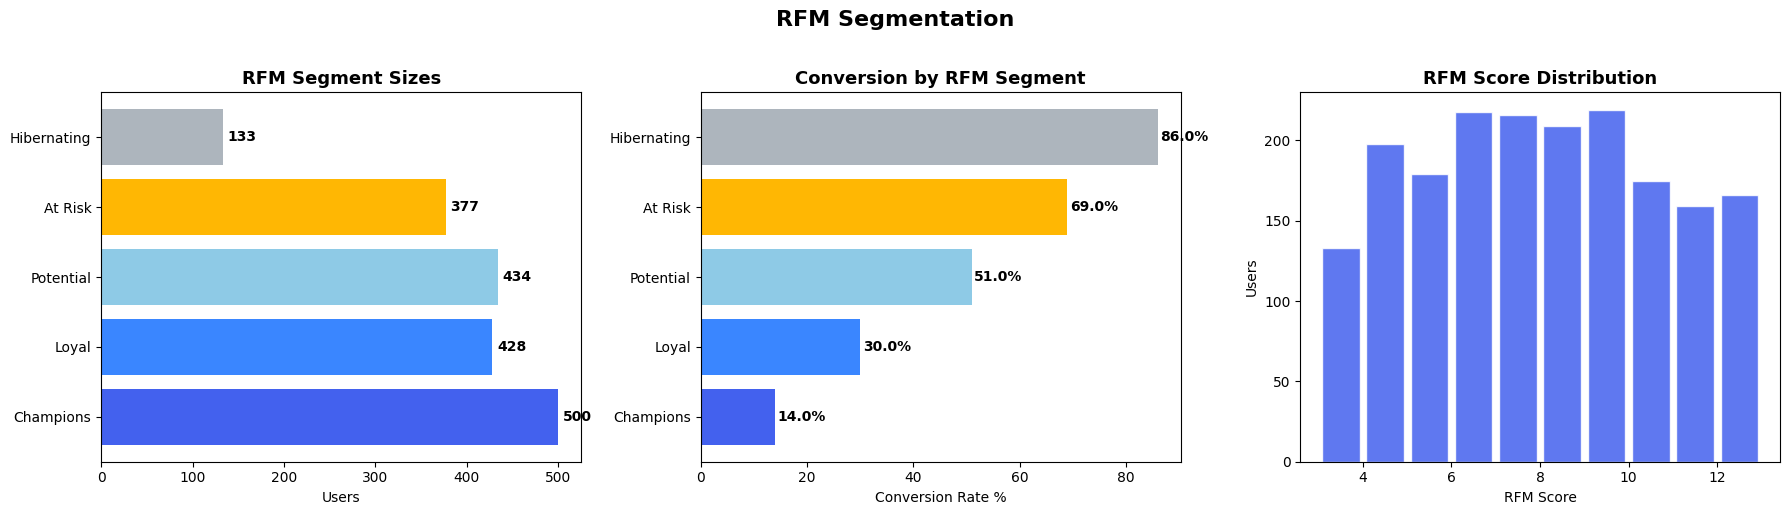

Saved 06_rfm_segmentation.png


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# 7a: Segment sizes
seg_order = rfm_summary.index.tolist()
seg_palette = {"Champions": "#4361ee", "Loyal": "#3a86ff", "Potential": "#8ecae6",
               "At Risk": "#ffb703", "Hibernating": "#adb5bd"}
axes[0].barh(seg_order, rfm_summary["users"],
             color=[seg_palette.get(s, "#4361ee") for s in seg_order])
axes[0].set_xlabel("Users")
axes[0].set_title("RFM Segment Sizes", fontsize=13, fontweight="bold")
for i, (seg, row) in enumerate(rfm_summary.iterrows()):
    axes[0].text(row["users"] + 5, i, str(int(row["users"])), va="center", fontweight="bold")
 
# 7b: Conv rate by RFM
axes[1].barh(seg_order, rfm_summary["conv_rate"],
             color=[seg_palette.get(s, "#4361ee") for s in seg_order])
axes[1].set_xlabel("Conversion Rate %")
axes[1].set_title("Conversion by RFM Segment", fontsize=13, fontweight="bold")
for i, (seg, row) in enumerate(rfm_summary.iterrows()):
    axes[1].text(row["conv_rate"] + 0.5, i, f"{row['conv_rate']}%", va="center", fontweight="bold")
 
# 7c: RFM Score distribution
axes[2].hist(rfm["rfm_score"], bins=range(3, 14), color="#4361ee",
             edgecolor="white", alpha=0.85, rwidth=0.85)
axes[2].set_xlabel("RFM Score")
axes[2].set_ylabel("Users")
axes[2].set_title("RFM Score Distribution", fontsize=13, fontweight="bold")
 
plt.suptitle("RFM Segmentation", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs_advanced/06_rfm_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 06_rfm_segmentation.png")

## 8️⃣  CART ABANDONMENT DEEP-DIVE

In [31]:
cart_sessions = df[df["PageType"] == "cart"]["SessionID"].unique()
cart_df = df[df["SessionID"].isin(cart_sessions)].copy()
 
cart_outcomes = cart_df.groupby("SessionID").agg(
    purchased=("Purchased", "max"),
    items=("ItemsInCart", "max"),
    device=("DeviceType", "first"),
    referral=("ReferralSource", "first"),
    country=("Country", "first"),
    total_time=("TimeOnPage_seconds", "sum"),
    pages=("PageType", "count"),
).reset_index()
cart_outcomes["outcome"] = cart_outcomes["purchased"].map({0: "Abandoned", 1: "Completed"})
 
total_cart = len(cart_outcomes)
abandoned = (cart_outcomes["purchased"] == 0).sum()
aband_rate = abandoned / total_cart * 100
print(f"🛒 Cart sessions: {total_cart}")
print(f"Abandoned: {abandoned} ({aband_rate:.1f}%)")
print(f"Completed: {total_cart - abandoned} ({100 - aband_rate:.1f}%)")
 
# By device
cart_by_device = cart_outcomes.groupby("device")["purchased"].agg(["count", "mean"]).round(3)
cart_by_device["abandon_rate"] = ((1 - cart_by_device["mean"]) * 100).round(1)
print("\nCart Abandonment by Device")
print(cart_by_device.to_string())
 
# By referral
cart_by_ref = cart_outcomes.groupby("referral")["purchased"].agg(["count", "mean"]).round(3)
cart_by_ref["abandon_rate"] = ((1 - cart_by_ref["mean"]) * 100).round(1)
print("\nCart Abandonment by Referral")
print(cart_by_ref.to_string())
 
# By items in cart
cart_by_items = cart_outcomes.groupby("items")["purchased"].agg(["count", "mean"]).round(3)
cart_by_items["abandon_rate"] = ((1 - cart_by_items["mean"]) * 100).round(1)
print("\nCart Abandonment by Items in Cart")
print(cart_by_items.to_string())

🛒 Cart sessions: 1599
Abandoned: 589 (36.8%)
Completed: 1010 (63.2%)

Cart Abandonment by Device
         count   mean  abandon_rate
device                             
Desktop    529  0.641          35.9
Mobile     537  0.628          37.2
Tablet     533  0.627          37.3

Cart Abandonment by Referral
              count   mean  abandon_rate
referral                                
Direct          386  0.630          37.0
Email           408  0.615          38.5
Google          427  0.649          35.1
Social Media    378  0.632          36.8

Cart Abandonment by Items in Cart
       count   mean  abandon_rate
items                            
0         77  0.000         100.0
1        302  0.709          29.1
2        306  0.644          35.6
3        360  0.708          29.2
4        277  0.632          36.8
5        277  0.610          39.0


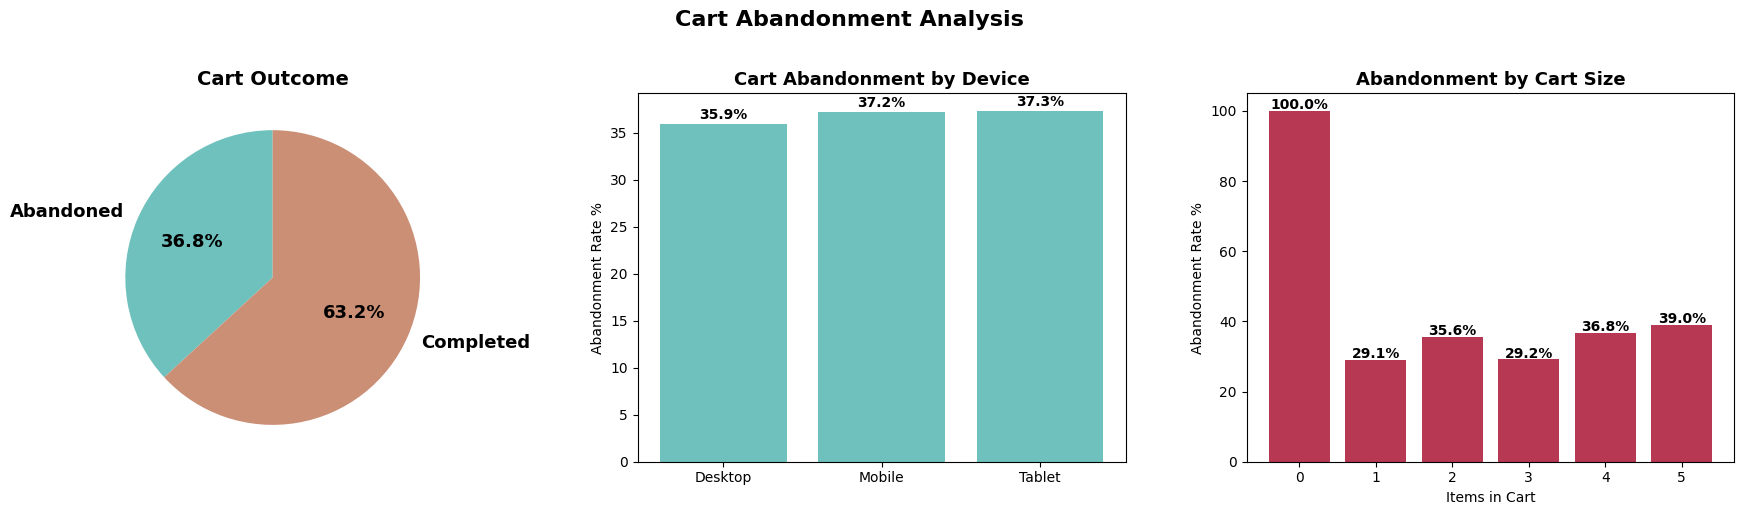

Saved 07_cart_abandonment.png


In [36]:
# Cart Abandon Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# 8a: Overall
axes[0].pie([abandoned, total_cart - abandoned],
            labels=["Abandoned", "Completed"], autopct="%1.1f%%",
            colors=["#6ec1bc", "#cb8f76"], startangle=90,
            textprops={"fontsize": 13, "fontweight": "bold"})
axes[0].set_title("Cart Outcome", fontsize=14, fontweight="bold")
 
# 8b: By device
x_dev = range(len(cart_by_device))
axes[1].bar(cart_by_device.index, cart_by_device["abandon_rate"], color="#6ec1bc")
axes[1].set_ylabel("Abandonment Rate %")
axes[1].set_title("Cart Abandonment by Device", fontsize=13, fontweight="bold")
for i, (idx, row) in enumerate(cart_by_device.iterrows()):
    axes[1].text(i, row["abandon_rate"] + 0.5, f"{row['abandon_rate']}%",
                 ha="center", fontweight="bold")
 
# 8c: By items
axes[2].bar(cart_by_items.index.astype(str), cart_by_items["abandon_rate"], color="#b73852")
axes[2].set_xlabel("Items in Cart")
axes[2].set_ylabel("Abandonment Rate %")
axes[2].set_title("Abandonment by Cart Size", fontsize=13, fontweight="bold")
for i, (idx, row) in enumerate(cart_by_items.iterrows()):
    axes[2].text(i, row["abandon_rate"] + 0.5, f"{row['abandon_rate']}%",
                 ha="center", fontweight="bold")
 
plt.suptitle("Cart Abandonment Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs_advanced/07_cart_abandonment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 07_cart_abandonment.png")

## 9️⃣  CROSS-DIMENSIONAL ANALYSIS

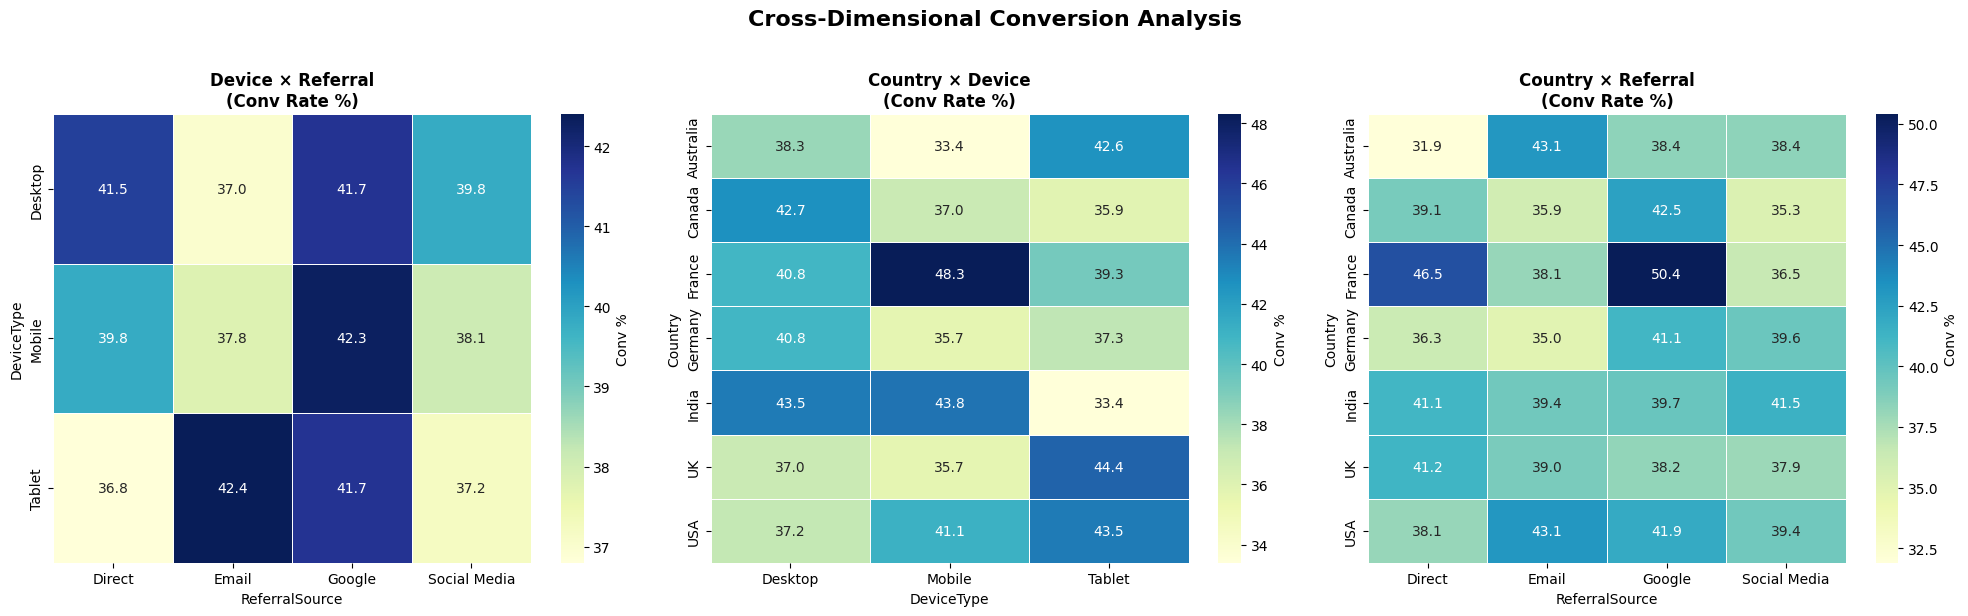

Saved 08_cross_dimensional.png


In [37]:
# Device × Referral heatmap
cross_dr = df.pivot_table(values="Purchased", index="DeviceType",
                          columns="ReferralSource", aggfunc="mean") * 100
 
# Country × Device heatmap
cross_cd = df.pivot_table(values="Purchased", index="Country",
                          columns="DeviceType", aggfunc="mean") * 100
 
# Country × Referral heatmap
cross_cr = df.pivot_table(values="Purchased", index="Country",
                          columns="ReferralSource", aggfunc="mean") * 100
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
 
sns.heatmap(cross_dr.round(1), annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0],
            linewidths=0.5, cbar_kws={"label": "Conv %"})
axes[0].set_title("Device × Referral\n(Conv Rate %)", fontsize=12, fontweight="bold")
 
sns.heatmap(cross_cd.round(1), annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1],
            linewidths=0.5, cbar_kws={"label": "Conv %"})
axes[1].set_title("Country × Device\n(Conv Rate %)", fontsize=12, fontweight="bold")
 
sns.heatmap(cross_cr.round(1), annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[2],
            linewidths=0.5, cbar_kws={"label": "Conv %"})
axes[2].set_title("Country × Referral\n(Conv Rate %)", fontsize=12, fontweight="bold")
 
plt.suptitle("Cross-Dimensional Conversion Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs_advanced/08_cross_dimensional.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 08_cross_dimensional.png")

## 🔟  FEATURE CORRELATION MATRIX

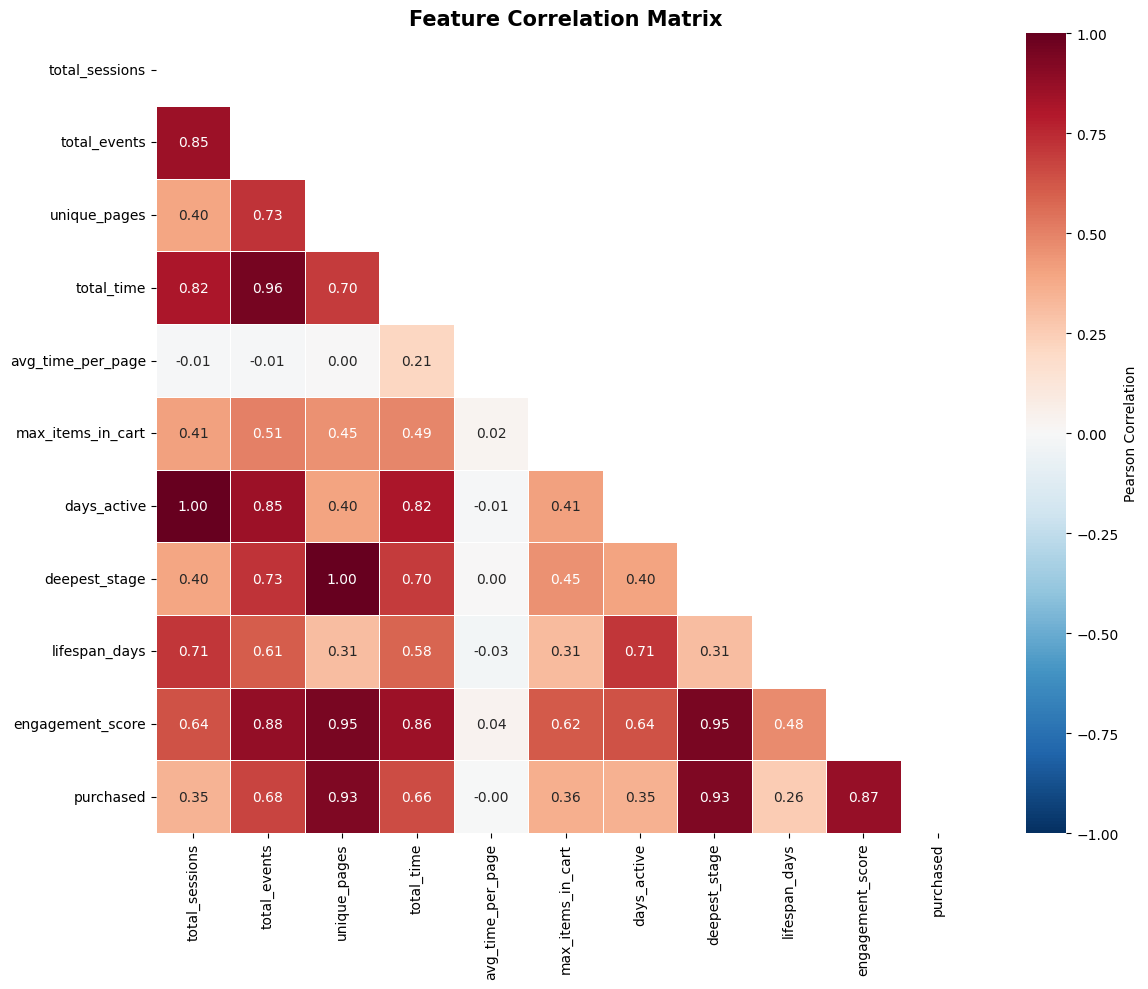

Saved 09_correlation_matrix.png

Correlation with Purchase
  unique_pages              +0.932  ███████████████████████████
  deepest_stage             +0.932  ███████████████████████████
  engagement_score          +0.871  ██████████████████████████
  total_events              +0.678  ████████████████████
  total_time                +0.655  ███████████████████
  max_items_in_cart         +0.365  ██████████
  days_active               +0.352  ██████████
  total_sessions            +0.349  ██████████
  lifespan_days             +0.257  ███████
  avg_time_per_page         -0.000  


In [39]:
corr_cols = [
    "total_sessions", "total_events", "unique_pages", "total_time",
    "avg_time_per_page", "max_items_in_cart", "days_active",
    "deepest_stage", "lifespan_days", "engagement_score", "purchased",
]
corr_matrix = user_features[corr_cols].corr()
 
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={"label": "Pearson Correlation"})
ax.set_title("Feature Correlation Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs_advanced/09_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 09_correlation_matrix.png")
 
# Top correlations with purchase
purchase_corr = corr_matrix["purchased"].drop("purchased").sort_values(ascending=False)
print("\nCorrelation with Purchase")
for feat, val in purchase_corr.items():
    bar = "█" * int(abs(val) * 30)
    sign = "+" if val > 0 else "-"
    print(f"  {feat:25s} {sign}{abs(val):.3f}  {bar}")

## EXECUTIVE SUMMARY & ADVANCED RECOMMENDATIONS

In [40]:
# Build dynamic insights
top_feat = feat_imp.tail(3).index.tolist()[::-1]
best_rfm = rfm_summary.index[0]
worst_rfm = rfm_summary.index[-1]
top_corr = purchase_corr.head(3)
 
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
📌 MARKOV CHAIN INSIGHTS
   • Home pages have a {trans_matrix.loc['home','product_page']:.0%} probability
     of leading to a product view
   • Cart → Exit probability: {trans_matrix.loc['cart','exit']:.0%}
     (key leakage point in the chain)
   • Once at checkout, {trans_matrix.loc['checkout','confirmation']:.0%}
     probability of completing purchase
 
📌 TEMPORAL INSIGHTS
   • Peak conversion hour: {int(best_hour['hour'])}:00 ({best_hour['conv_rate']}%)
   • Best converting day: {best_day}
   • Optimize ad spend and email sends around these windows
 
📌 PREDICTIVE MODEL PERFORMANCE
   • Random Forest AUC: {rf_auc:.3f} (5-Fold CV: {rf_cv:.3f})
   • Top predictive features: {', '.join(top_feat)}
   • Model can identify likely buyers with high accuracy
 
📌 RFM SEGMENTATION
   • "{best_rfm}" segment has highest conversion
     ({rfm_summary.loc[best_rfm, 'conv_rate']}%)
   • "{worst_rfm}" segment needs re-engagement
     ({rfm_summary.loc[worst_rfm, 'conv_rate']}% conv)
 
📌 CART ABANDONMENT
   • {aband_rate:.1f}% of cart sessions are abandoned
   • Recovery campaigns targeting these users could recapture
     significant revenue
 
📌 STATISTICAL FINDINGS
   • Device effect: {'Significant' if p_dev < 0.05 else 'Not significant'}
     (p={p_dev:.4f})
   • Referral effect: {'Significant' if p_ref < 0.05 else 'Not significant'}
     (p={p_ref:.4f})
   • Session duration strongly differs between converters & non-converters
     (p={p_mw:.4f})
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
🎯 STRATEGIC RECOMMENDATIONS
 
   1. DEPLOY REAL-TIME SCORING: Use the engagement scoring model
      to trigger personalized interventions when users are "Hot"
      but haven't purchased yet.
 
   2. TIME-TARGETED CAMPAIGNS: Schedule push notifications, emails,
      and retargeting ads during peak conversion windows
      (hour {int(best_hour['hour'])}:00, {best_day}s).
 
   3. CART RECOVERY AUTOMATION: Implement abandoned cart emails
      within 1 hour — {aband_rate:.0f}% of carts are abandoned,
      representing the single largest revenue recovery opportunity.
 
   4. REACTIVATE "{worst_rfm.upper()}" SEGMENT: This group has
      {rfm_summary.loc[worst_rfm, 'users']:.0f} users with
      {rfm_summary.loc[worst_rfm, 'conv_rate']}% conversion.
      Win-back campaigns with incentives could lift this.
 
   5. NURTURE "CHAMPIONS": Your top RFM segment
      ({rfm_summary.loc[best_rfm, 'users']:.0f} users) drives
      disproportionate value — loyalty programs and referral
      incentives will maximize LTV.
 
   6. A/B TEST HIGH-IMPACT TRANSITIONS: The Markov chain shows
      cart → exit as the critical leakage point. Test checkout
      UX simplification, guest checkout, and trust badges.
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
 


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 MARKOV CHAIN INSIGHTS
   • Home pages have a 80% probability
     of leading to a product view
   • Cart → Exit probability: 30%
     (key leakage point in the chain)
   • Once at checkout, 90%
     probability of completing purchase

📌 TEMPORAL INSIGHTS
   • Peak conversion hour: 15:00 (45.71%)
   • Best converting day: Sunday
   • Optimize ad spend and email sends around these windows

📌 PREDICTIVE MODEL PERFORMANCE
   • Random Forest AUC: 1.000 (5-Fold CV: 1.000)
   • Top predictive features: deepest_stage, unique_pages, total_events
   • Model can identify likely buyers with high accuracy

📌 RFM SEGMENTATION
   • "Champions" segment has highest conversion
     (14.0%)
   • "Hibernating" segment needs re-engagement
     (86.0% conv)

📌 CART ABANDONMENT
   • 36.8% of cart sessions are abandoned
   • Recovery campaigns targeting these users could recapture
     significant revenue

📌 STATISTICAL FINDINGS
   • Device ef